In [2]:
# !pip install git+https://github.com/openai/CLIP.git

import clip
import kagglehub
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os, requests
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
from PIL import Image, ImageFilter
from io import BytesIO
from collections import defaultdict

random.seed(42)
np.random.seed(42)

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-cferhnfa
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-cferhnfa
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done


*Part 1*

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)
clip_model.eval()

CIFAR10_trainset = datasets.CIFAR10(root='./data', train=True, download=True, transform=clip_preprocess)
CIFAR10_testset = datasets.CIFAR10(root='./data', train=False, download=True, transform=clip_preprocess)

CIFAR10_trainloader = DataLoader(CIFAR10_trainset, batch_size=64, shuffle=True, num_workers=2)
CIFAR10_testloader = DataLoader(CIFAR10_testset, batch_size=64, shuffle=False, num_workers=2)

CIFAR10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

PACS_basepath = kagglehub.dataset_download("nickfratto/pacs-dataset")
PACS_sketch = datasets.ImageFolder(root=f"{PACS_basepath}/dct2_images/dct2_images/sketch", transform=clip_preprocess)

print(len(PACS_sketch))
print(len(CIFAR10_testset))
PACS_testloader  = DataLoader(PACS_sketch, batch_size=64, shuffle=False, num_workers=2)

PACS_cartoon = datasets.ImageFolder(root=f"{PACS_basepath}/dct2_images/dct2_images/cartoon",transform=clip_preprocess)
print(len(PACS_cartoon))

100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 119MiB/s]
100%|██████████| 170M/170M [00:02<00:00, 78.0MB/s]


100%|██████████| 526M/526M [00:08<00:00, 66.2MB/s]

Extracting files...


3929
10000
2344


In [7]:
CIFAR10_prompts=[f"a photo of a {label}" for label in CIFAR10_classes]
PACS_prompts=[f"a drawing of a {label}" for label in PACS_sketch.classes]

def compute_accuracy(dataloader, prompts):
  with torch.no_grad():
    text_tokens = clip.tokenize(prompts).to(device)
    text_features = clip_model.encode_text(text_tokens).to(device)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    total, correct = 0, 0
    total_per_class, correct_per_class = defaultdict(int), defaultdict(int)

    for images, labels in dataloader:
      images, labels = images.to(device), labels.to(device)

      image_features = clip_model.encode_image(images).to(device)
      image_features /= image_features.norm(dim=-1, keepdim=True)

      similarities = (image_features @ text_features.T) * 100
      predictions = similarities.argmax(dim=-1)

      correct += (predictions == labels).sum().item()
      total += labels.size(0)

      for pred, true in zip(predictions, labels):
        total_per_class[true.item()] += 1
        if pred.item() == true.item():
            correct_per_class[true.item()] += 1

  acc_per_class = {}
  for c in range(len(CIFAR10_classes)):
      if total_per_class[c] > 0:
          acc_per_class[c] = round(100 * correct_per_class[c] / total_per_class[c], 2)
      else:
          acc_per_class[c] = 0.0

  if CIFAR10_classes:
    acc_per_class = {CIFAR10_classes[i]: acc_per_class[i] for i in range(len(CIFAR10_classes))}

  return round((correct / total) * 100, 2), acc_per_class


In [12]:
cifar_zeroshot_overall_accuracy, cifar_zeroshot_perclass_accuracy=compute_accuracy(CIFAR10_testloader, CIFAR10_prompts)
print(f"CIFAR10 Accuracy: {cifar_zeroshot_overall_accuracy}%")
print("CIFAR10 Per Class Accuracy")
print(cifar_zeroshot_perclass_accuracy)

pacs_zeroshot_overall_accuracy, _=compute_accuracy(PACS_testloader, PACS_prompts)
print(f"PACS Accuracy: {pacs_zeroshot_overall_accuracy}%")

CIFAR10 Accuracy: 88.73%
CIFAR10 Per Class Accuracy
{'airplane': 90.0, 'automobile': 97.6, 'bird': 88.9, 'cat': 85.9, 'deer': 76.5, 'dog': 88.3, 'frog': 77.2, 'horse': 97.6, 'ship': 95.5, 'truck': 89.8}
PACS Accuracy: 19.85%


*Part 2*

In [ ]:
CIFAR10_engineered_prompts=[[f"an image of a {label}" for label in CIFAR10_classes],
                            [f"a colored picture of a {label}" for label in CIFAR10_classes],
                            [f"a cropped image of a {label}" for label in CIFAR10_classes],
                            ]
PACS_engineered_prompts=[[f"a black and white drawing of a {label}" for label in PACS_sketch.classes],
                          [f"a pencil drawing of a {label}" for label in PACS_sketch.classes],
                          [f"a line drawing of a {label}" for label in PACS_sketch.classes]
                          ]

cifar_fewshot_accuracy=[accuracy for accuracy in map(lambda prompts: compute_accuracy(CIFAR10_testloader, prompts), CIFAR10_engineered_prompts)]
print(f"CIFAR10 Accuracies: {cifar_fewshot_accuracy}")

pacs_fewshot_accuracy=[accuracy for accuracy in map(lambda prompts: compute_accuracy(PACS_testloader, prompts), PACS_engineered_prompts)]
print(f"PACS Accuracies: {pacs_fewshot_accuracy}")


CIFAR10 Accuracies: [89.11, 88.24, 88.66]
PACS Accuracies: [14.2494, 4.9618, 11.9593]


*Part 3*

In [ ]:
def sample_one_per_class(dataset, class_names, num_samples):
  samples = []
  seen = set()
  i = 0
  while len(seen) < num_samples and i < len(dataset):
      img, label = dataset[i]
      if label not in seen:
          seen.add(label)
          samples.append((img, label, class_names[label]))
      i += 1
  return samples

cifar_samples = sample_one_per_class(CIFAR10_testset, CIFAR10_classes, 10)
pacs_sketch_samples = sample_one_per_class(PACS_sketch, PACS_sketch.classes, 5)
pacs_cartoon_samples = sample_one_per_class(PACS_cartoon, PACS_cartoon.classes, 5)
print(len(pacs_cartoon_samples))

samples = cifar_samples + pacs_sketch_samples + pacs_cartoon_samples
domains = (["CIFAR"]*len(cifar_samples) + ["PACS-sketch"]*len(pacs_sketch_samples) + ["PACS-cartoon"]*len(pacs_cartoon_samples))

cifar_queries = [f"a photo of a {c}" for _,_,c in cifar_samples]
sketch_queries = [f"a drawing of a {c}" for _,_,c in pacs_sketch_samples]
cartoon_queries = [f"a cartoon of a {c}" for _,_,c in pacs_cartoon_samples]

queries = cifar_queries + sketch_queries + cartoon_queries
expected_class_names = [c for _,_,c in samples]

image_tensors = torch.stack([img[0] for img in samples], dim=0).to(device)

with torch.no_grad():
  text_tokens = clip.tokenize(queries).to(device)
  text_features = clip_model.encode_text(text_tokens).to(device)
  text_features /= text_features.norm(dim=-1, keepdim=True)

  image_features = clip_model.encode_image(image_tensors).to(device)
  image_features /= image_features.norm(dim=-1, keepdim=True)

similarities = (text_features @ image_features.T).cpu().numpy()
top1_indices = similarities.argmax(axis=1)

correct = 0
rows = []
for i, q in enumerate(queries):
    retrieved_idx = int(top1_indices[i])
    retrieved_name = samples[retrieved_idx][2]
    retrieved_domain = domains[retrieved_idx]
    true_domain = domains[i]
    expected = expected_class_names[i]
    is_correct = (retrieved_name == expected)
    if is_correct: correct += 1
    rows.append((q, expected, retrieved_name, true_domain, retrieved_domain, is_correct))

acc = correct / len(queries) * 100.0
print(f"Text→Image top-1 accuracy on this 20-query pool: {acc:.1f}%\n")

print(f"{'Query':60} {'Expected':12} {'Retrieved':12} {'RetrievedDom':14} {'TrueDom':12} {'OK'}")
for q, exp, ret, ret_dom, true_dom, ok in rows:
    print(f"{q[:58]:60} {exp:12} {ret:12} {true_dom:14} {ret_dom:12} {str(ok)}")


5
Text→Image top-1 accuracy on this 20-query pool: 55.0%

Query                                                        Expected     Retrieved    RetrievedDom   TrueDom      OK
a photo of a cat                                             cat          giraffe      PACS-cartoon   CIFAR        False
a photo of a ship                                            ship         ship         CIFAR          CIFAR        True
a photo of a airplane                                        airplane     dog          PACS-cartoon   CIFAR        False
a photo of a frog                                            frog         frog         CIFAR          CIFAR        True
a photo of a automobile                                      automobile   automobile   CIFAR          CIFAR        True
a photo of a truck                                           truck        truck        CIFAR          CIFAR        True
a photo of a dog                                             dog          horse        PACS-cartoon   

*Part 4*

In [4]:
def sample_images(num_cifar=10, num_sketch=10, num_cartoon=10):
  samples = []

  cifar_indices = random.sample(range(len(CIFAR10_testset)), num_cifar)
  for idx in cifar_indices:
      img, label = CIFAR10_testset[idx]
      samples.append((img, CIFAR10_classes[label], "CIFAR-10"))

  sketch_indices = random.sample(range(len(PACS_sketch)), num_sketch)
  for idx in sketch_indices:
      img, label = PACS_sketch[idx]
      samples.append((img, PACS_sketch.classes[label], "PACS-sketch"))

  cartoon_indices = random.sample(range(len(PACS_cartoon)), num_cartoon)
  for idx in cartoon_indices:
      img, label = PACS_cartoon[idx]
      samples.append((img, PACS_cartoon.classes[label], "PACS-cartoon"))

  return samples

samples = sample_images()

labels_list = [f"{label} ({domain})" for _, label, domain in samples]
image_tensors = torch.stack([img for img, _, _ in samples], dim=0).to(device)

clip_image_embeddings = []
with torch.no_grad():
  image_features = clip_model.encode_image(image_tensors).to(device)
  image_features /= image_features.norm(dim=-1, keepdim=True)
clip_image_embeddings = image_features.cpu().numpy()

label_encoder = LabelEncoder()
label_ids = label_encoder.fit_transform(labels_list)
n_labels = len(label_encoder.classes_)

resnet_embeddings = np.load("/content/resnet_embeddings.npy")

clip_image_2d=TSNE(n_components=2, random_state=42, perplexity=5).fit_transform(clip_image_embeddings)
resnet_image_2d=TSNE(n_components=2, random_state=42, perplexity=5).fit_transform(resnet_embeddings)

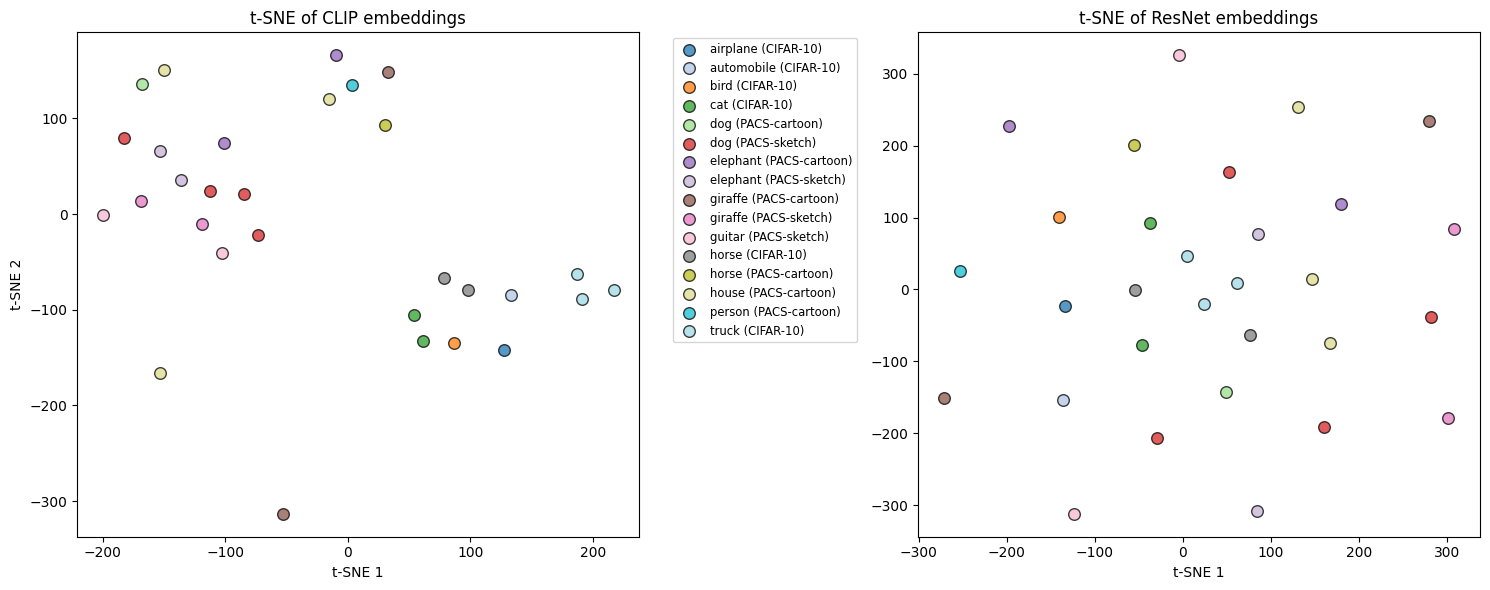

In [5]:
cmap = plt.get_cmap("tab20")
if n_labels <= 20:
    colors = cmap(np.linspace(0, 1, n_labels))
else:
    colors = plt.cm.hsv(np.linspace(0, 1, n_labels))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for i, cls in enumerate(label_encoder.classes_):
    idxs = np.where(label_ids == i)[0]
    axes[0].scatter(clip_image_2d[idxs, 0], clip_image_2d[idxs, 1],
                    color=colors[i], label=cls, s=70, alpha=0.75, edgecolor="k")
axes[0].set_title("t-SNE of CLIP embeddings")
axes[0].set_xlabel("t-SNE 1")
axes[0].set_ylabel("t-SNE 2")
axes[0].legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small")

for i, cls in enumerate(label_encoder.classes_):
    idxs = np.where(label_ids == i)[0]
    axes[1].scatter(resnet_image_2d[idxs, 0], resnet_image_2d[idxs, 1],
                    color=colors[i], label=cls, s=70, alpha=0.75, edgecolor="k")
axes[1].set_title("t-SNE of ResNet embeddings")
axes[1].set_xlabel("t-SNE 1")

plt.tight_layout()
plt.show()


*Part 5*

In [ ]:
urls = [
    "https://raw.githubusercontent.com/rgeirhos/texture-vs-shape/master/stimuli/style-transfer-preprocessed-512/airplane/airplane1-bicycle2.png",
    "https://raw.githubusercontent.com/rgeirhos/texture-vs-shape/master/stimuli/style-transfer-preprocessed-512/bear/bear1-bird2.png",
    "https://raw.githubusercontent.com/rgeirhos/texture-vs-shape/master/stimuli/style-transfer-preprocessed-512/boat/boat1-car2.png",
    "https://raw.githubusercontent.com/rgeirhos/texture-vs-shape/master/stimuli/style-transfer-preprocessed-512/cat/cat1-chair2.png",
    "https://raw.githubusercontent.com/rgeirhos/texture-vs-shape/master/stimuli/style-transfer-preprocessed-512/elephant/elephant1-dog2.png",
]

save_dir = "sample_cue_conflict"
os.makedirs(save_dir, exist_ok=True)

cue_images, cue_image_names = [], []
for url in urls:
    fname = url.split("/")[-1]
    outpath = os.path.join(save_dir, fname)

    r = requests.get(url)
    r.raise_for_status()
    with open(outpath, "wb") as f:
        f.write(r.content)

    img = Image.open(BytesIO(r.content)).convert("RGB")
    cue_images.append(clip_preprocess(img).unsqueeze(0))
    cue_image_names.append(fname.split(".")[0])

cue_images = torch.cat(cue_images).to(device)

In [ ]:

cue_pairs = []
all_prompts = []
for fname in cue_image_names:
    shape_part, texture_part = fname.split("-")
    shape = ''.join([c for c in shape_part if not c.isdigit()])
    texture = ''.join([c for c in texture_part if not c.isdigit()])

    shape_prompt = f"a photo of a {shape}"
    texture_prompt = f"a photo of a {texture}"

    all_prompts.append(shape_prompt)
    all_prompts.append(texture_prompt)
    cue_pairs.append((fname, shape_prompt, texture_prompt))

unique_prompts = list(dict.fromkeys(all_prompts))

with torch.no_grad():
  text_tokens = clip.tokenize(unique_prompts).to(device)
  text_features = clip_model.encode_text(text_tokens).to(device)
  text_features /= text_features.norm(dim=-1, keepdim=True)

  image_features = clip_model.encode_image(cue_images).to(device)
  image_features /= image_features.norm(dim=-1, keepdim=True)

similarities = (image_features @ text_features.T).cpu().numpy()

prompt_to_idx = {p: i for i, p in enumerate(unique_prompts)}
results = []

for i, (fname, shape_prompt, texture_prompt) in enumerate(cue_pairs):
  sim_shape = similarities[i, prompt_to_idx[shape_prompt]]
  sim_texture = similarities[i, prompt_to_idx[texture_prompt]]

  if sim_shape > sim_texture:
      prediction = "shape"
  elif sim_texture > sim_shape:
      prediction = "texture"
  else:
      prediction = "tie"

  results.append({
      "filename": fname,
      "shape_prompt": shape_prompt,
      "texture_prompt": texture_prompt,
      "sim_shape": float(sim_shape),
      "sim_texture": float(sim_texture),
      "prediction": prediction
  })

df = pd.DataFrame(results)
print(df)

             filename           shape_prompt        texture_prompt  sim_shape  \
0  airplane1-bicycle2  a photo of a airplane  a photo of a bicycle   0.291950   
1         bear1-bird2      a photo of a bear     a photo of a bird   0.271069   
2          boat1-car2      a photo of a boat      a photo of a car   0.216012   
3         cat1-chair2       a photo of a cat    a photo of a chair   0.202778   
4      elephant1-dog2  a photo of a elephant      a photo of a dog   0.290644   

   sim_texture prediction  
0     0.231175      shape  
1     0.220571      shape  
2     0.254503    texture  
3     0.281080    texture  
4     0.264182      shape  


*Part 6*

In [ ]:
indices = random.sample(range(len(CIFAR10_testset)), 25)
perturb_sample_images = [CIFAR10_testset[i] for i in indices]

perturbations = {
    "gaussian_blur": transforms.GaussianBlur(kernel_size=5),
    "color_jitter": transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
    "random_noise": lambda img: Image.fromarray(
        (np.array(img) + np.random.normal(0, 25, img.size[::-1] + (3,))).clip(0,255).astype(np.uint8)
    ),
    "cartoon": lambda img: img.filter(ImageFilter.CONTOUR),
}

perturbed_tensors, perturbed_labels = [], []
for name, perturb in perturbations.items():
    for img, label in perturb_sample_images:
        if isinstance(img, torch.Tensor):
            img = transforms.ToPILImage()(img)

        out = perturb(img) if callable(perturb) else perturb(img)

        tensor_out = clip_preprocess(out).unsqueeze(0)
        perturbed_tensors.append(tensor_out)
        perturbed_labels.append((CIFAR10_classes[label], name))

perturbed_tensors = torch.cat(perturbed_tensors).to(device)

perturb_prompts = [f"a photo of a {lbl}" for lbl, _ in perturbed_labels]

with torch.no_grad():
  text_tokens = clip.tokenize(perturb_prompts).to(device)
  text_features = clip_model.encode_text(text_tokens).to(device)
  text_features /= text_features.norm(dim=-1, keepdim=True)

  image_features = clip_model.encode_image(perturbed_tensors).to(device)
  image_features /= image_features.norm(dim=-1, keepdim=True)

similarities = (image_features @ text_features.T).cpu().numpy()
predictions = similarities.argmax(axis=1)
pred_classes = [perturb_prompts[i] for i in predictions]

correct = 0
perturb_results = []
for i, ((true_class, perturbation), pred_class) in enumerate(zip(perturbed_labels, pred_classes)):
    is_correct = true_class in pred_class
    correct += int(is_correct)
    perturb_results.append({
        "Image #": i,
        "Perturbation": perturbation,
        "True Label": true_class,
        "Predicted": pred_class,
        "Correct?": is_correct
    })

accuracy = correct / len(perturbed_labels)
print(f"Accuracy: {accuracy:.2f}")

print("Sample results")
perturb_result_indices = random.sample(range(len(perturb_results)), 10)
perturb_result_samples = [perturb_results[i] for i in perturb_result_indices]
for r in perturb_result_samples:
  print(r)



Accuracy: 0.31
Sample results
{'Image #': 15, 'Perturbation': 'gaussian_blur', 'True Label': 'ship', 'Predicted': 'a photo of a frog', 'Correct?': False}
{'Image #': 72, 'Perturbation': 'random_noise', 'True Label': 'ship', 'Predicted': 'a photo of a automobile', 'Correct?': False}
{'Image #': 31, 'Perturbation': 'color_jitter', 'True Label': 'ship', 'Predicted': 'a photo of a frog', 'Correct?': False}
{'Image #': 74, 'Perturbation': 'random_noise', 'True Label': 'horse', 'Predicted': 'a photo of a frog', 'Correct?': False}
{'Image #': 76, 'Perturbation': 'cartoon', 'True Label': 'airplane', 'Predicted': 'a photo of a airplane', 'Correct?': True}
{'Image #': 5, 'Perturbation': 'gaussian_blur', 'True Label': 'frog', 'Predicted': 'a photo of a frog', 'Correct?': True}
{'Image #': 79, 'Perturbation': 'cartoon', 'True Label': 'horse', 'Predicted': 'a photo of a horse', 'Correct?': True}
{'Image #': 10, 'Perturbation': 'gaussian_blur', 'True Label': 'bird', 'Predicted': 'a photo of a horse'

In [ ]:
def compute_perturbation_accuracy(perturb_results):
    stats = defaultdict(lambda: {"correct": 0, "total": 0})

    for result in perturb_results:
        pert = result["Perturbation"]
        stats[pert]["total"] += 1
        if result["Correct?"]:
            stats[pert]["correct"] += 1

    accuracy_per_perturb = {pert: round(100 * stats[pert]["correct"] / stats[pert]["total"], 2) for pert in stats}

    return accuracy_per_perturb

perturb_accuracy = compute_perturbation_accuracy(perturb_results)
print("Accuracy per perturbation:")
for perturb, acc in perturb_accuracy.items():
    print(f"{perturb}: {acc}%")

Accuracy per perturbation:
gaussian_blur: 24.0%
color_jitter: 24.0%
random_noise: 24.0%
cartoon: 16.0%
